In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

In [2]:
# Load the CSV file
file_path = "data/FullJoin3_with_climate_ratings-proofed.csv"
df = pd.read_csv(file_path)

# Display first few rows
display(df.head())

,AccNoFull,ItemAccNoFull,LocationName,LocationCoordY,LocationCoordX,LifeForm,Family,Genus,GenusSpecies,ItemLocationCode,...,ItemType,IUCNRedList,NationalRedList,RegionalRedList,Locality,LocalityFull,climate_rating_emissions_limited_2040,climate_rating_current_sheet,climate_rating_business_as_usual_2080,climate_rating_bau_plus_1degree_2080
0,1999-0404,1999-0404.01,Contemporary Garden,-123.246025,49.253365,Shrub,Oleaceae,Abeliophyllum,Abeliophyllum distichum,1C01,...,Planting,NaN,NaN,NaN,NaN,NaN,9.0,11.0,3.0,3.0
1,2014-0168,2014-0168.01,Asian Garden,-123.251150,49.253642,Shrub,Oleaceae,Abeliophyllum,Abeliophyllum distichum,3AAF,...,Planting,NaN,NaN,NaN,NaN,NaN,9.0,11.0,3.0,3.0
2,1983-0427,1983-0427.01,Alpine Garden,-123.246104,49.253650,Shrub,Pinaceae,Abies,Abies koreana,LAS4,...,Planting,NaN,NaN,NaN,NaN,NaN,6.0,9.0,5.0,5.0
3,1987-0067,1987-0067.01,Alpine Garden,-123.246737,49.254134,Shrub,Pinaceae,Abies,Abies balsamea,LNA3,...,Planting,NaN,NaN,NaN,NaN,NaN,6.0,9.0,3.0,3.0
4,1987-0067,1987-0067.02,Alpine Garden,-123.246714,49.254241,Shrub,Pinaceae,Abies,Abies balsamea,LNA1,...,Planting,NaN,NaN,NaN,NaN,NaN,6.0,9.0,3.0,3.0


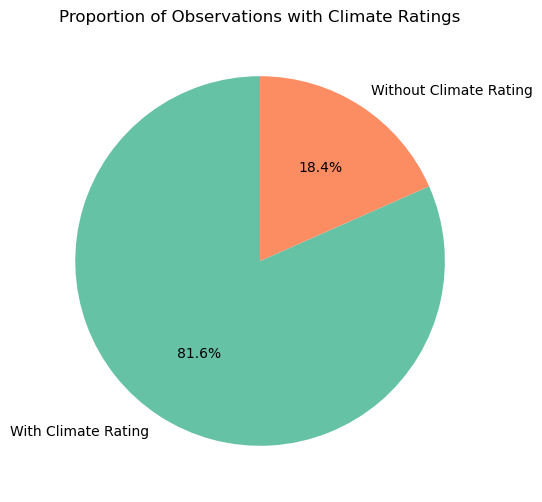

In [3]:
# Check which columns contain climate ratings
climate_rating_cols = [col for col in df.columns if 'climate_rating' in col]

# Determine if any climate rating is missing (NaN) per observation
df['HasClimateRating'] = df[climate_rating_cols].notna().any(axis=1)

# Calculate proportions
portion_with_rating = df['HasClimateRating'].mean()
portion_without_rating = 1 - portion_with_rating

# Create visualization
plt.figure(figsize=(8, 6))
plt.pie(
    [portion_with_rating, portion_without_rating], 
    labels=["With Climate Rating", "Without Climate Rating"], 
    autopct='%1.1f%%', startangle=90, colors=['#66c2a5', '#fc8d62']
)
plt.title("Proportion of Observations with Climate Ratings")
plt.show()


In [11]:
# Filter for observations that are trees or shrubs
tree_shrub_df = df[df['LifeForm'].str.lower().isin(['tree', 'shrub'])]

# Calculate proportions for trees and shrubs having climate ratings
tree_shrub_with_rating = tree_shrub_df['HasClimateRating'].mean()
tree_shrub_without_rating = 1 - tree_shrub_with_rating

# Prepare a readable result
tree_shrub_result = pd.DataFrame({
    "Category": ["With Climate Rating", "Without Climate Rating"],
    "Proportion": [tree_shrub_with_rating, tree_shrub_without_rating]
})
display(tree_shrub_result)

# Filter for observations classified as herbaceous
herbaceous_df = df[df['LifeForm'].str.lower().str.contains('herbaceous')]

# Calculate proportions for herbaceous material having climate ratings
herbaceous_with_rating = herbaceous_df['HasClimateRating'].mean()
herbaceous_without_rating = 1 - herbaceous_with_rating

# Prepare a readable result
herbaceous_result = pd.DataFrame({
    "Category": ["With Climate Rating", "Without Climate Rating"],
    "Proportion": [herbaceous_with_rating, herbaceous_without_rating]
})
display(herbaceous_result)

,Category,Proportion
0,With Climate Rating,0.834769
1,Without Climate Rating,0.165231


,Category,Proportion
0,With Climate Rating,0.778531
1,Without Climate Rating,0.221469


# Top 10 family with largest change in climate rating

In [12]:
# Calculate the change in climate ratings over time (2025 to 2080)
climate_ratings_trimmed = df[['Family', 
                              'climate_rating_current_sheet', 
                              'climate_rating_emissions_limited_2040', 
                              'climate_rating_business_as_usual_2080']].dropna()

# Calculate changes in climate ratings
climate_ratings_trimmed['Change_2025_to_2040'] = climate_ratings_trimmed['climate_rating_emissions_limited_2040'] - climate_ratings_trimmed['climate_rating_current_sheet']
climate_ratings_trimmed['Change_2040_to_2080'] = climate_ratings_trimmed['climate_rating_business_as_usual_2080'] - climate_ratings_trimmed['climate_rating_emissions_limited_2040']
climate_ratings_trimmed['Total_Change_2025_to_2080'] = climate_ratings_trimmed['climate_rating_business_as_usual_2080'] - climate_ratings_trimmed['climate_rating_current_sheet']

# Aggregate by plant family to see mean directional change and variation within families
family_trends = climate_ratings_trimmed.groupby('Family').agg({
    'Change_2025_to_2040': ['mean', 'std'],
    'Change_2040_to_2080': ['mean', 'std'],
    'Total_Change_2025_to_2080': ['mean', 'std']
}).reset_index()

# Flatten column names
family_trends.columns = ['Family', 'Mean_Change_2025_to_2040', 'Std_Change_2025_to_2040', 
                         'Mean_Change_2040_to_2080', 'Std_Change_2040_to_2080', 
                         'Mean_Total_Change_2025_to_2080', 'Std_Total_Change_2025_to_2080']

# Sort by total mean change to highlight rapidly changing families
family_trends_sorted = family_trends.sort_values(by='Mean_Total_Change_2025_to_2080', ascending=False)

# Display the top families with the largest changes
display(family_trends_sorted.head(10))


,Family,Mean_Change_2025_to_2040,Std_Change_2025_to_2040,Mean_Change_2040_to_2080,Std_Change_2040_to_2080,Mean_Total_Change_2025_to_2080,Std_Total_Change_2025_to_2080
61,Dilleniaceae,3.000000,NaN,3.000000,NaN,6.000000,NaN
135,Pittosporaceae,1.500000,1.581139,2.600000,0.966092,4.100000,1.197219
3,Akaniaceae,1.000000,0.000000,3.000000,0.000000,4.000000,0.000000
87,Heliotropiaceae,0.000000,NaN,4.000000,NaN,4.000000,NaN
49,Commelinaceae,0.000000,1.414214,3.000000,0.000000,3.000000,1.414214
79,Gelsemiaceae,3.000000,0.000000,0.000000,0.000000,3.000000,0.000000
170,Tapisciaceae,3.000000,0.000000,0.000000,0.000000,3.000000,0.000000
172,Tecophilaeaceae,3.000000,NaN,0.000000,NaN,3.000000,NaN
131,Pentaphylacaceae,0.857143,1.406422,1.857143,1.994498,2.714286,1.589803
97,Lardizabalaceae,1.558824,1.778511,1.088235,1.864625,2.647059,1.612120


In [13]:
# Determine portions of observations moving into the 0-3 climate rating zone
portion_below_threshold_2040 = (climate_ratings_trimmed['climate_rating_emissions_limited_2040'] <= 3).mean()
portion_below_threshold_2080 = (climate_ratings_trimmed['climate_rating_business_as_usual_2080'] <= 3).mean()

# Prepare a readable result
climate_threshold_result = pd.DataFrame({
    "Year": ["2040", "2080"],
    "Proportion <= 3": [portion_below_threshold_2040*100, portion_below_threshold_2080*100]
})
display(climate_threshold_result)

,Year,Proportion <= 3
0,2040,2.687315
1,2080,12.176421


# Family Over-representation 

The overrepresentation factor measures how much more common a plant family is in the subset of observations moving into the 0-3 climate rating zone (by 2080) compared to its overall representation in the dataset.

### How it's calculated:
$$
\text{Overrepresentation Factor} =
\frac{\text{Overall proportion of family in the dataset}}{\text{Proportion of family in 0-3 climate rating}}
$$

 
### Interpreting the values:
A value of 1 means the family is equally represented in the 0-3 climate rating as it is in the overall dataset.
A value greater than 1 indicates overrepresentation, meaning the family is disproportionately affected and more common in the 0-3 zone compared to its normal frequency.
For example, an overrepresentation factor of 8 (like we saw with families such as Juncaceae or Typhaceae) means that these families are 8 times more common in the group of plants likely to face unsuitable conditions by 2080 than expected based on their overall presence.

The overrepresentation factor might help identify plant families that are disproportionately vulnerable to climate change.

In [14]:
# Filter observations that move into the 0-3 climate rating zone in 2080
below_threshold_2080 = climate_ratings_trimmed[climate_ratings_trimmed['climate_rating_business_as_usual_2080'] <= 3]

# Calculate family proportions within the below-threshold subset
family_counts_below_threshold = below_threshold_2080['Family'].value_counts(normalize=True)

# Calculate overall family proportions in the full dataset
overall_family_proportions = climate_ratings_trimmed['Family'].value_counts(normalize=True)

# Compare the proportion of each family in the below-threshold subset to its overall representation
overrepresentation = (family_counts_below_threshold / overall_family_proportions).sort_values(ascending=False)

# Display the top overrepresented families
display(overrepresentation.head(10))

Family
Juncaceae           8.212594
Lentibulariaceae    8.212594
Typhaceae           8.212594
Tofieldiaceae       8.212594
Polygalaceae        8.212594
Woodsiaceae         8.212594
Gentianaceae        7.246406
Montiaceae          6.022569
Elaeocarpaceae      5.475062
Caryophyllaceae     4.754659
Name: proportion, dtype: float64